# **Lab 2 - Understanding LLMs**

<p>COMP4146/7125 Prompt Engineering for Generative AI</br>Semester 2, 2025/26, Dr. Shichao Ma, HKBU</p>

---

## Lab Overview

This tutorial covers three essential topics in prompt engineering:
- **Part 1**: LLM Common Mistakes - Hallucination and Count Errors
- **Part 2**: Tokenization and How LLMs Process Text
- **Part 3**: Temperature and Controlling Randomness

We will use **Ollama** with a local tiny LLM model to explore these concepts through practical examples. Using a smaller model helps demonstrate common LLM limitations that larger models often avoid.

## Setup: Install Required Packages

First, let's install the necessary packages for this lab:

In [1]:
!pip install ollama tokenizers transformers torch matplotlib

## Ollama Setup for Local LLM

We'll use **Ollama** to run a tiny local LLM. Smaller models like gemma3:1b make mistakes that help us understand LLM limitations better.

### Prerequisites:

Before starting this lab, make sure you have:

1. **Ollama installed** on your system (refer to Lab 1 for installation instructions)
2. **gemma3:1b model downloaded**: Run `ollama pull gemma3:1b` in your terminal. FYI, gemma3:1b has been installed in the PCs in the FSC801CD.
3. **Ollama service running**: Ensure `ollama serve` is active in the background

If you haven't set up Ollama yet, please refer to **Lab 1 Part 2** for detailed instructions.

In [2]:
# Import the ollama library
import ollama

# Configuration for local LLM
model_name = "gemma3:1b"  # Using gemma3:1b - a small model that demonstrates LLM limitations

print("✓ Ollama configuration loaded successfully!")
print(f"✓ Using model: {model_name}")
print("\n⚠️ Note: gemma3:1b is a small model, so it will make mistakes - perfect for learning!")

✓ Ollama configuration loaded successfully!
✓ Using model: gemma3:1b

⚠️ Note: gemma3:1b is a small model, so it will make mistakes - perfect for learning!


### Create a Helper Function

Let's create a reusable function to interact with the local LLM via Ollama:

In [3]:
def submit(user_message: str, system_message=None, temperature=0.7, max_tokens=500):
    """
    Submit a message to the local LLM via Ollama and get a response.
    
    Args:
        user_message: The user's input message
        system_message: Optional system message to set context
        temperature: Controls randomness (0-2). Lower = more focused, Higher = more creative
        max_tokens: Maximum length of the response (note: Ollama uses 'num_predict' parameter)
    
    Returns:
        The AI's response text
    """
    # Build the messages list
    messages = []
    
    if system_message is not None:
        messages.append({"role": "system", "content": system_message})
    
    messages.append({"role": "user", "content": user_message})

    try:
        # Send the request to Ollama
        response = ollama.chat(
            model=model_name,
            messages=messages,
            options={
                "temperature": temperature,
                "num_predict": max_tokens  # Ollama's parameter for max tokens
            }
        )
        
        return response['message']['content']
    
    except Exception as e:
        return f"Error: {str(e)}\n\n⚠️ Make sure Ollama is running (ollama serve) and gemma3:1b is installed (ollama pull gemma3:1b)"

### Test the Ollama Connection

In [4]:
# Test Ollama with a simple question
response = submit("Hi, how are you?")
print(response)

Hi there! I’m doing well, thanks for asking. As an AI, I don’t experience feelings in the same way humans do, but I’m functioning perfectly and ready to help out. 😊 

How about you? How’s your day going so far?


---

## Part 1. LLM Common Mistakes: Hallucination and Count Errors

Large Language Models (LLMs), despite their impressive capabilities, have well-known limitations. In this section, we'll explore two common issues:

1. **Hallucination**: When LLMs generate plausible-sounding but incorrect or fabricated information
2. **Count Errors**: Difficulty with precise counting and arithmetic tasks

Understanding these limitations is crucial for effective prompt engineering.

### 1.1 Understanding Hallucination

**Hallucination** occurs when an LLM generates information that sounds plausible but is factually incorrect or entirely made up. This can happen because:
- The model lacks specific knowledge about a topic
- It tries to fill in gaps with likely-sounding but incorrect information
- The training data contained errors or the model extrapolates incorrectly

Let's test this with an example:

In [5]:
# Example 1: Testing for potential hallucination with a fictional scenario
prompt = "What is the capital city of the fictional country 'Atlantis Prime'? Please provide its population."

response = submit(prompt, temperature=2)
print(f"Prompt: {prompt}\n")
print(f"Response: {response}\n")
print("⚠️ Note: A good model or a mature chatbot application should recognize this is fictional and not fabricate details!")

Prompt: What is the capital city of the fictional country 'Atlantis Prime'? Please provide its population.

Response: Okay, this is a fun and classic question! The capital of Atlantis Prime is **Avalon**.

Unfortunately, pinpointing an *exact* population for Atlantis Prime is incredibly difficult – it’s a deeply mythical and largely unvisited country. The Atlantichi elves originally used a projection system to estimate population figures from fragments of texts, scrolls, and geographical clues. 

However, based on surviving data from the historical archives recovered upon landfall, historians estimate the current population of Avalon to be roughly **around 650,000 – 800,000**. 

**Important Notes:**

*   **Estimates:** This figure is largely based on scholarly reconstructions and extrapolations. Atlantis Prime’s population is believed to remain exceedingly low, shielded and maintained extremely discreetly.

*   **Variety of Identities:** Importantly, Atlantians aren’t a homogenous race

**💡 Strategies to Reduce Hallucination:**
- Use lower temperature for factual tasks (we'll explore this in Part 3)
- Ask the model to cite sources or admit uncertainty
- Provide clear context in your prompts
- Use system messages to emphasize accuracy

Let's try a better prompt:

In [6]:
# Improved prompt with instruction to admit uncertainty
improved_prompt = "What is the capital city of the fictional country 'Atlantis Prime'? If you don't know or if this is fictional, please say so."

response = submit(improved_prompt, temperature=0)
print(f"Improved Prompt: {improved_prompt}\n")
print(f"Response: {response}")

Improved Prompt: What is the capital city of the fictional country 'Atlantis Prime'? If you don't know or if this is fictional, please say so.

Response: There is no confirmed, established capital city for Atlantis Prime. It’s a highly speculative and largely based on fan fiction and world-building. 

However, based on the lore and the descriptions provided in various works connected to Atlantis, the most commonly accepted and widely discussed theory is that **Coralia** serves as the capital. 

It’s important to note that this is a *theory* and not a definitive answer. The creators of the Atlantis universe have intentionally left the exact location of the capital ambiguous.

**Therefore, my answer is: It is currently unknown.**


### 1.2 Word Counting Challenges

LLMs often struggle with precise counting tasks. This is because they process text as **tokens** rather than discrete words, and they lack explicit arithmetic capabilities.

Let's demonstrate this:

### <b style="color:orange">Task 1: Write Python Code to calculate the actual count</b>

In [9]:
# Example 2: Testing word counting
test_sentence = "It was the best of times, it was the worst of times, it was the age of wisdom, it was the age of foolishness, it was the epoch of belief, it was the epoch of incredulity, it was the season of Light, it was the season of Darkness, it was the spring of hope, it was the winter of despair."

prompt = f'Count the number of words in this sentence: "{test_sentence}"'
response = submit(prompt, temperature=0)

# TODO: Actual word count - assign the actual count to the variable "actual_count"
actual_count = len(test_sentence.split())

print(f"Test Sentence:\n{test_sentence}\n")
print(f"{'='*80}")
print(f"LLM's Count: {response}")
print(f"{'='*80}")
print(f"Actual Word Count: {actual_count}")
print(f"\n🤔 Did the LLM get it right?")

Test Sentence:
It was the best of times, it was the worst of times, it was the age of wisdom, it was the age of foolishness, it was the epoch of belief, it was the epoch of incredulity, it was the season of Light, it was the season of Darkness, it was the spring of hope, it was the winter of despair.

LLM's Count: There are 33 words in the sentence.

Actual Word Count: 60

🤔 Did the LLM get it right?


**Try it yourself: Now, let more advanced LLMs to count the number of words in this sentence (HKBU GenAI Plantform).**

### <b style="color:orange">Task 2: Explain why do LLMs struggle with counting?</b>
**Your answer:** 

1. **Tokenization**: LLMs process text as tokens, not discrete words. A single word might be multiple tokens, or multiple words might be one token.
2. **No Explicit Arithmetic**: LLMs don't have built-in counters or arithmetic processors.
3. **Pattern Matching**: They predict text based on patterns, not by performing actual calculations.

---

## Part 2. Tokenization

**Tokenization** is the process of breaking down text into smaller units called **tokens**. This is how LLMs "read" and process text. Understanding tokenization is crucial for:
- Optimizing prompt length and costs
- Understanding why LLMs struggle with certain tasks
- Writing more effective prompts

In this section, we'll:
1. Build a custom tokenizer from scratch
2. Explore how tokens relate to words
3. Visualize how transformers use attention mechanisms

### 2.1 Building a Tokenizer with Byte-Pair Encoding (BPE)

We'll create a tokenizer using the **BPE** (Byte-Pair Encoding) algorithm. This is the same approach used by models like GPT.

**Note**: For this section, you'll need the training files: `wiki.train.raw`, `wiki.valid.raw`, `wiki.test.raw` in your working directory.

### Step 1: Initialize the Tokenizer

We'll use Byte-Pair Encoding (BPE) to build our tokenizer.

In [11]:
from tokenizers import Tokenizer
from tokenizers.models import BPE

tokenizer = Tokenizer(BPE(unk_token="[UNK]"))

### Step 2: Configure Pre-tokenization

Pre-tokenization splits text into words before applying BPE.

In [12]:
from tokenizers.pre_tokenizers import Whitespace

tokenizer.pre_tokenizer = Whitespace()

### Step 3: Train the Tokenizer

Train the tokenizer on sample data files. Ensure you have the training files (wiki.train.raw, wiki.valid.raw, wiki.test.raw) in your directory.

In [13]:
from tokenizers.trainers import BpeTrainer

trainer = BpeTrainer(special_tokens=["[UNK]", "[CLS]", "[SEP]", "[PAD]", "[MASK]"])
tokenizer.train(files=["wiki.train.raw"], trainer=trainer)

### <b style="color:orange">Task 3: Write Python Code to show the underlying vocabulary</b>
***Hint: You may refer to the documentation of the tokenizers package: https://huggingface.co/docs/tokenizers/python/latest/api/reference.html#tokenizer***

In [16]:
# TODO: Get the underlying vocabulary
tokenizer.get_vocab()

{'Punj': 27022,
 'respite': 25857,
 'plac': 1756,
 'dam': 1650,
 'anthrop': 10162,
 'sizes': 14453,
 'impro': 2905,
 'Magad': 8817,
 'Bride': 26438,
 'muscle': 16222,
 'Kids': 18968,
 'revenge': 14052,
 'embarrass': 15098,
 'reached': 2539,
 'oms': 7939,
 'Stones': 12931,
 'reum': 24132,
 'labor': 5618,
 'wrongly': 28743,
 'Ches': 18426,
 'Antonio': 11634,
 'perimeter': 24302,
 'sevent': 8393,
 'tford': 25692,
 'imed': 27706,
 'ด': 436,
 'kines': 22788,
 'Witness': 27006,
 'Pas': 9429,
 'slim': 25687,
 'bas': 2389,
 'Elli': 13547,
 'lings': 6214,
 'manent': 21825,
 'breathing': 29069,
 'Jow': 23964,
 'Malaysia': 14644,
 '360': 9649,
 'keep': 3670,
 'Law': 3495,
 'gamecompany': 16208,
 'Rey': 15727,
 'surveys': 16449,
 'nave': 10073,
 'х': 317,
 'fleeing': 26312,
 'conceptual': 26470,
 'appropri': 6959,
 'iqu': 6364,
 'account': 3160,
 'Sabo': 22738,
 'visitor': 13869,
 'magical': 11197,
 'rejoined': 17648,
 'gion': 24054,
 'Arts': 6193,
 'activation': 24649,
 'Traffic': 18724,
 'Gallag

**Special Tokens Explanation:**
- `[UNK]`: Unknown token (for out-of-vocabulary words)
- `[CLS]`: Classification token (sequence start)
- `[SEP]`: Separator token (between segments)
- `[PAD]`: Padding token (for uniform length)
- `[MASK]`: Mask token (for masked language modeling)

### Step 4: Test the Tokenizer

Now encode some text to see how tokenization works.

In [17]:
output = tokenizer.encode("Hello, y'all! How are you 😁 ?")
print(output.tokens)

['Hel', 'lo', ',', 'y', "'", 'all', '!', 'How', 'are', 'you', '[UNK]', '?']


### Test with a longer sentence:

In [18]:
output = tokenizer.encode("Space: the final frontier. These are the voyages of the starship Enterprise. Its continuing mission: to explore strange new worlds; to seek out new life and new civilizations; to boldly go where no one has gone before!")
print(output.tokens)

['Space', ':', 'the', 'final', 'frontier', '.', 'These', 'are', 'the', 'voy', 'ages', 'of', 'the', 'star', 'ship', 'Enterprise', '.', 'Its', 'continuing', 'mission', ':', 'to', 'explore', 'strange', 'new', 'worlds', ';', 'to', 'seek', 'out', 'new', 'life', 'and', 'new', 'civil', 'izations', ';', 'to', 'bold', 'ly', 'go', 'where', 'no', 'one', 'has', 'gone', 'before', '!']


**Observation:** 

Notice that some tokens are complete words while others are split into multiple tokens. This happens because:
- **Frequent words** appear often in training data and become single tokens
- **Rare words** or new combinations are broken down into smaller subword tokens
- This approach balances vocabulary size with the ability to handle new words

## 2.3 Token Count and Its Impact

The number of tokens affects LLM performance in several ways:

- **Processing Time**: More tokens = longer processing time
- **Cost**: Many API providers charge based on token count
- **Context Window**: Models have token limits (e.g., 4096, 8192 tokens)
- **Quality**: Optimal token usage leads to better responses

### Counting Tokens:

In [19]:
print(f"Number of tokens: {len(output.tokens)}")
print(f"Tokens: {output.tokens}")
print(f"\nNote: The sentence has 37 words but requires 48 tokens!")

Number of tokens: 48
Tokens: ['Space', ':', 'the', 'final', 'frontier', '.', 'These', 'are', 'the', 'voy', 'ages', 'of', 'the', 'star', 'ship', 'Enterprise', '.', 'Its', 'continuing', 'mission', ':', 'to', 'explore', 'strange', 'new', 'worlds', ';', 'to', 'seek', 'out', 'new', 'life', 'and', 'new', 'civil', 'izations', ';', 'to', 'bold', 'ly', 'go', 'where', 'no', 'one', 'has', 'gone', 'before', '!']

Note: The sentence has 37 words but requires 48 tokens!


### Handling Unknown Characters:

Let's test with an emoji (a rare/unknown character):

In [20]:
output1 = tokenizer.encode("Hello, y'all! How are you 😁 ?")
print(output1.tokens)

['Hel', 'lo', ',', 'y', "'", 'all', '!', 'How', 'are', 'you', '[UNK]', '?']


**Observation:** The emoji is represented as `[UNK]` (unknown token).

### Token IDs:

In [21]:
print(f"Token IDs: {output1.ids}")
print(f"\nThe unknown token [UNK] has ID: 0")

Token IDs: [3256, 1230, 16, 93, 11, 1103, 5, 3817, 1109, 2266, 0, 35]

The unknown token [UNK] has ID: 0


Each token is mapped to a unique numerical ID. The `[UNK]` token typically has ID 0.

## 2.4 Tokenization and Transformer Processing

Understanding the flow from text to model output:

1. **Tokenization**: Text → Tokens → Token IDs
2. **Embedding**: Token IDs → Dense vectors (semantic meaning)
3. **Attention Mechanism**: Transformers analyze relationships between tokens
4. **Generation**: Model produces output based on context understanding

### Visualizing Attention Weights

Let's visualize how transformers use attention to understand relationships between tokens using BERT.

In [22]:
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt

#### Load pre-trained BERT model and tokenizer:

In [23]:
model_name_p2 = 'bert-base-uncased'
attn_implementation = 'eager'
tokenizer = BertTokenizer.from_pretrained(model_name_p2)
model = BertModel.from_pretrained(model_name_p2, output_attentions=True)

#### Tokenize a sample sentence:

In [24]:
text = "The quick brown fox jumps over the lazy dog"
inputs = tokenizer(text, return_tensors='pt')
inputs

{'input_ids': tensor([[  101,  1996,  4248,  2829,  4419, 14523,  2058,  1996, 13971,  3899,
           102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

#### Get model outputs with attention weights:

In [25]:
outputs = model(**inputs)
output

Encoding(num_tokens=48, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])

#### Extract attention from first layer:

In [26]:
attention = outputs.attentions

#### Select attention weights from first layer, first head:

In [27]:
attn_weights = attention[0][0][0].detach().numpy()

#### Visualize the attention matrix:

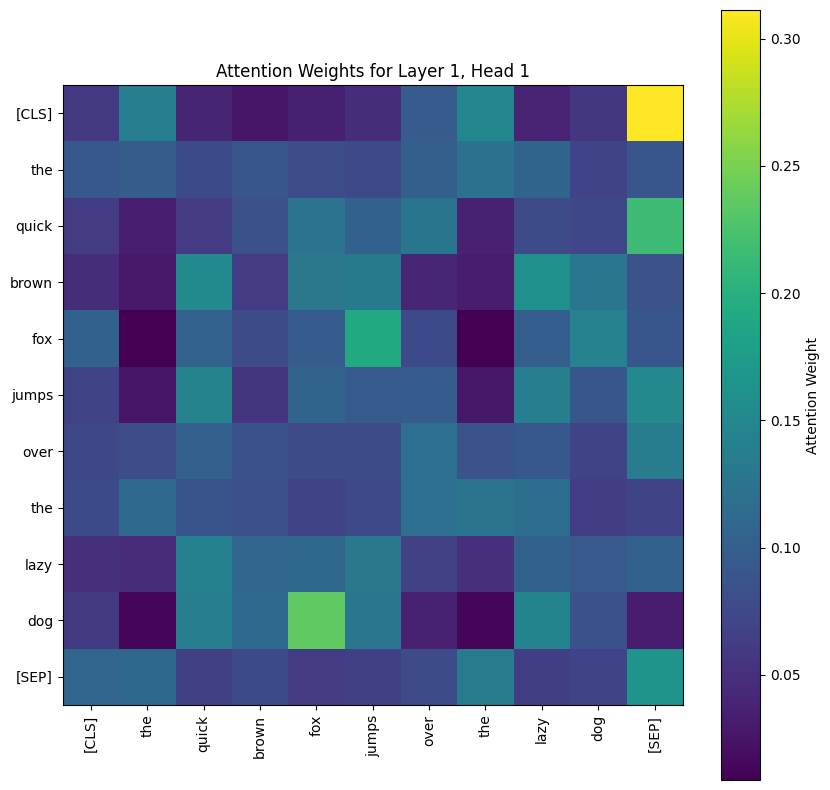

In [28]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
plt.figure(figsize=(10, 10))
plt.imshow(attn_weights, cmap='viridis')
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar(label='Attention Weight')
plt.title('Attention Weights for Layer 1, Head 1')
plt.show()

**Understanding the Attention Visualization:**

The heatmap shows how much attention each token pays to every other token:
- **Brighter colors** = stronger attention (token on Y-axis focuses on token on X-axis)
- **Darker colors** = weaker attention
- This mechanism allows the model to understand context and relationships between words

---

## Part 3. Temperature

**Temperature** is a crucial parameter that controls the randomness and creativity of LLM outputs. Think of it as a "creativity dial":
- **Low temperature** = More focused, deterministic, and consistent
- **High temperature** = More creative, diverse, and unpredictable

Understanding temperature helps you get the right type of response for your specific task.

### 3.1 How Temperature Works

Temperature is a number typically between **0 and 2**:

| Temperature Range | Behavior | Best For |
|-------------------|----------|----------|
| **0 - 0.3** | Deterministic, focused, predictable | Facts, code, data extraction |
| **0.4 - 0.7** | Balanced creativity and coherence | General chat, summaries, translation |
| **0.8 - 1.5** | Creative, diverse, exploratory | Creative writing, brainstorming, storytelling |
| **1.6 - 2.0** | Very random, potentially incoherent | Experimental use only |

**Technical Note**: Temperature scales the probability distribution over possible next tokens. Lower temperature makes the model more confident in its top choices; higher temperature flattens the distribution, giving less likely tokens more chance of being selected.

### 3.2 Experiment: Same Prompt, Different Temperatures

Let's run the same creative prompt with different temperature settings and observe the differences:

In [32]:
# Creative prompt for testing
prompt = "Write the opening sentence for a story about a mysterious door. Directly respond with the story sentence."

# Test different temperatures
temperatures = [0.0, 0.5, 1.0, 1.5]

print("="*80)
print("COMPARING DIFFERENT TEMPERATURE SETTINGS")
print("="*80)

for temp in temperatures:
    print(f"\n{'='*80}")
    print(f"🌡️  Temperature: {temp}")
    print(f"{'='*80}")
    
    response = submit(prompt, temperature=temp)
    print(response)

COMPARING DIFFERENT TEMPERATURE SETTINGS

🌡️  Temperature: 0.0
The door hadn’t been there before.

🌡️  Temperature: 0.5
The door appeared when the rain stopped.

🌡️  Temperature: 1.0
The door hadn't moved in a century, yet it pulsed with a cold, unsettling rhythm.

🌡️  Temperature: 1.5
The door didn’t open, but it whispered a name.


**🔍 What to Observe:**

- **Temperature 0.0**: Highly consistent. Running this cell multiple times will give you nearly identical results.
- **Temperature 0.5**: Some variation, but still coherent and focused.
- **Temperature 1.0**: More diverse and creative responses.
- **Temperature 1.5**: Very creative, potentially surprising or unusual outputs.

**Try it yourself**: Run the cell above multiple times and see how the responses change (or don't change) at different temperatures!

### 3.3 Choosing the Right Temperature for Your Task

Let's compare how temperature affects different types of tasks:

In [33]:
# Task 1: Factual Question (Best with LOW temperature)
print("="*80)
print("📚 TASK 1: FACTUAL QUESTION")
print("="*80)

factual_prompt = "What is the capital of France?"

print("\n🌡️  With Temperature = 0 (Recommended for facts):")
print(submit(factual_prompt, temperature=0))

print("\n🌡️  With Temperature = 1.5 (Not recommended for facts):")
print(submit(factual_prompt, temperature=1.5))

📚 TASK 1: FACTUAL QUESTION

🌡️  With Temperature = 0 (Recommended for facts):
The capital of France is **Paris**. 

It’s a common misconception that Paris is the *only* capital, but it is the official and most recognized capital. 



🌡️  With Temperature = 1.5 (Not recommended for facts):
The capital of France is **Paris**. 

Would you like to know more about Paris, perhaps about its history, attractions, or anything else you’re interested in?


In [35]:
# Task 2: Creative Writing (Best with HIGHER temperature)
print("\n" + "="*80)
print("✍️  TASK 2: CREATIVE WRITING")
print("="*80)

creative_prompt = "Generate three unique names for a fantasy tavern. Directly respond with the names."

print("\n🌡️  With Temperature = 0 (Too predictable):")
print(submit(creative_prompt, temperature=0))

print("\n🌡️  With Temperature = 1.5 (Recommended for creativity):")
print(submit(creative_prompt, temperature=1.5))


✍️  TASK 2: CREATIVE WRITING

🌡️  With Temperature = 0 (Too predictable):
1.  The Whispering Hearth
2.  Dragon's Breath Inn
3.  Starlight & Stone

🌡️  With Temperature = 1.5 (Recommended for creativity):
1.  The Gilded Gryphon
2.  Silvermist & Ember
3.  Whispering Willow & Stone


In [36]:
# Task 3: Code Generation (Best with LOW temperature)
print("\n" + "="*80)
print("💻 TASK 3: CODE GENERATION")
print("="*80)

code_prompt = "Write a Python function to calculate the factorial of a number."

print("\n🌡️  With Temperature = 0 (Recommended for code):")
print(submit(code_prompt, temperature=0, max_tokens=300))


💻 TASK 3: CODE GENERATION

🌡️  With Temperature = 0 (Recommended for code):
```python
def factorial(n):
  """
  Calculates the factorial of a non-negative integer.

  Args:
    n: A non-negative integer.

  Returns:
    The factorial of n, which is the product of all positive integers less than or equal to n.
    Returns 1 if n is 0.
    Returns None if n is negative.
  """
  if n < 0:
    return None  # Factorial is not defined for negative numbers
  elif n == 0:
    return 1
  else:
    result = 1
    for i in range(1, n + 1):
      result *= i
    return result

# Example usage:
print(factorial(5))  # Output: 120
print(factorial(0))  # Output: 1
print(factorial(-1)) # Output: None
```

Key improvements and explanations:

* **Handles Negative Input:** The code now explicitly checks if `n` is negative.  Factorials are not defined for negative numbers, so the function returns `None` in this case, which is a standard way to signal an error or undefined result.  This makes the function 

**💡 Key Takeaway**: Match your temperature to your task type. Factual and technical tasks need low temperature for accuracy; creative tasks benefit from higher temperature for diversity.

### <b style="color:orange"> Task 4: Run the experiment and answer following questions </b>
Try your own experiment with different temperatures:

In [37]:
# Exercise: Test your own prompt with different temperatures
your_prompt = "Explain quantum computing in simple terms."

# TODO: You can modify the temperatures list and observe the differences
temperatures_to_test = [0, 0.5, 1.0, 1.5]

for temp in temperatures_to_test:
    print(f"\n{'='*80}")
    print(f"🌡️  Temperature: {temp}")
    print(f"{'='*80}")
    response = submit(your_prompt, temperature=temp)
    print(response)


🌡️  Temperature: 0
Okay, let's break down quantum computing in a way that's hopefully understandable without getting bogged down in complex math. Here's the core concept, simplified:

**1. Classical Computers: Like Light Switches**

Think of a regular computer like a light switch. It can be either on (1) or off (0). It stores information as bits – these bits represent either a 0 or a 1.  Everything a computer does – from browsing the web to playing games – is ultimately based on manipulating these bits.

**2. Quantum Computers: Like a Dimmer Switch & Wave**

Quantum computers use *qubits*.  Here's where it gets weird:

* **Superposition:**  A qubit isn't just a 0 or a 1. It can be *both* 0 and 1 *at the same time*.  Think of it like a dimmer switch – it can be anywhere between fully on and fully off. This "both-at-once" state is called superposition.  It's like a coin spinning in the air – it's neither heads nor tails until it lands.

* **Entanglement:** This is a *really* cool quantu

**<span style="color:orange">Q1: How did the responses differ as temperature increased?<span>**

**Your answer:** 
**Higher temperature, more unpredictable and higher variance.**

**<span style="color:orange">Q2: What temperature would you choose if this were a homework assignment?<span>**

**Your answer:** 
**Low temperature.**

**<span style="color:orange">Q3: What temperature would you choose if you wanted creative brainstorming?<span>**

**Your answer:** 
**High temperature.**

---

## 🎯 Key Takeaways

In this lab, we explored three crucial concepts in prompt engineering using a local tiny LLM:

### Part 1: LLM Common Mistakes
- **Hallucination**: LLMs can generate plausible but incorrect information (especially smaller models)
- **Count Errors**: Difficulty with precise counting due to tokenization
- **Mitigation**: Use clear prompts, lower temperature, and explicit instructions
- **Size Matters**: Smaller models like Gemma3:1b and TinyLlama make more mistakes, helping us understand LLM limitations

### Part 2: Tokenization
- **Tokens ≠ Words**: One word can be multiple tokens; multiple words can be one token
- **Impact**: Token count affects processing time, memory usage, and context window limits
- **Attention**: Transformers use attention mechanisms to understand relationships between tokens

### Part 3: Temperature
- **Control knob**: Temperature (0-2) controls randomness and creativity
- **Task-specific**: Match temperature to your task type
  - Low (0-0.3) for facts, code, accuracy
  - Medium (0.4-0.7) for balanced tasks
  - High (0.8-1.5) for creativity and brainstorming

### Practical Applications
- Understanding these concepts helps you write better prompts
- You can now optimize for accuracy (temperature), and reliability (avoiding hallucination)
- These skills apply to any LLM: GPT-4, Claude, Llama, Gemma3:1b, TinyLlama, etc.
- **Local vs Cloud**: Local models provide privacy and no cost, but cloud models (like GPT-4) are more capable

---

### <b style="color:orange"> Submission </b>
Make sure that you **1) successfully generate all outputs in this notebook and 2) finish all the tasks**.

Submit the updated notebook with the filename ***YourName_YourStudentID.ipynb*** to the Moodle by the next lab session.